In [1]:
!pip install maldideepkit --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted at /content/drive')
except ImportError:
    print('Running locally -- skipping Google Drive mount')


Mounted at /content/drive
Google Drive mounted at /content/drive


# MaldiMLPClassifier Analysis on Binned MALDI-TOF Spectra

This notebook classifies **antimicrobial resistance** using the
**MaldiMLPClassifier** from MaldiDeepKit on the DRIAMS Duroux dataset
(*Staphylococcus aureus*, 2018 cohort).

We use **MaldiDeepKit's preprocessing functions** (`fit_input_transform` /
`apply_input_transform`) for leak-safe log1p + standardisation — the same
pipeline as the logistic regression baseline — then apply four increasingly
sophisticated MLP configurations.

---
## Companion notebooks

| Notebook | Method |
|---|---|
| `0-0-2-LogisticAnalysis` | Logistic regression baseline |
| `0-0-1-1-Tuning` | Hyperparameter tuning (all architectures) |
| `0-0-4-MLPClassifier` | **This notebook** — MaldiMLPClassifier |

Both notebooks generate a `report.md` for direct method comparison.

---
## What this notebook covers

1. Load 14,112 binned spectra (6,000 bins, 3 Da resolution) + metadata
2. Preprocess with MaldiDeepKit (log1p + standardise, fit on train only)
3. **Approach A** — baseline MLP (no dropout, no weight decay)  exposes overfitting
4. **Approach B** — regularised MLP with full 4×4 grid search (lr × dropout) + threshold tuning
5. **Approach C** — attention MLP (sigmoid-gated attention) + threshold tuning + per-bin interpretation
6. **Approach D** — wide MLP (hidden_dim=1024, 3-layer head) + threshold tuning
7. Comparison summary (BalAcc, ROC-AUC, confusion matrices, ROC curves)
8. Repeat on a second drug (Imipenem) for generalisability
9. **LR vs MLP comparison report** — saved as `report.md`


In [3]:
# =============================================================================
# 1. IMPORTS & CONFIGURATION
# =============================================================================

# --- Standard library ---
import warnings          # suppress FutureWarning noise from sklearn/pandas
from pathlib import Path # cross-platform path handling

# --- Numerical & data manipulation ---
import numpy as np       # matrix operations, .npy loading
import pandas as pd      # CSV metadata, pivot tables

# --- Plotting ---
import matplotlib.pyplot as plt  # bar charts, ROC curves, confusion matrices

# --- PyTorch (backend for MaldiDeepKit) ---
import torch

# --- MaldiDeepKit: preprocessing layer (same as LR notebook) ---
from maldideepkit.base.data import (
    fit_input_transform,    # compute per-bin mean/std from training split only
    apply_input_transform,  # apply log1p / standardise / robust to any split
)

# --- MaldiDeepKit: MLP classifier ---
from maldideepkit.attention.mlp import MaldiMLPClassifier

# --- Scikit-learn: metrics & visualisation ---
from sklearn.metrics import (
    accuracy_score,             # fraction correct
    balanced_accuracy_score,    # mean of per-class recall (handles imbalance)
    f1_score,                   # harmonic mean of precision & recall
    roc_auc_score,              # area under ROC (threshold-independent)
    ConfusionMatrixDisplay,     # visual confusion matrix
    RocCurveDisplay,            # visual ROC curve
)

# Suppress excessive warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


# --- Paths ---
# Local (uncomment if running on your machine)
#DATA_DIR = Path("../../A2018/A2018")
#OUT_DIR  = Path("./results_mlp")

# Colab (uncomment if running on Google Colab)
DATA_DIR = Path("/content/drive/MyDrive/Flower/Duroux_D_dirams/A2018/A2018")
OUT_DIR  = Path("/content/drive/MyDrive/Flower/Duroux_D_dirams/0-Analysis/0-0-4-MLPClassifier/results_mlp")

SPECTRA_PATH   = DATA_DIR / "rawSpectra_data.npy"
SPLITS_PATH    = DATA_DIR / "data_splits.csv"
LONG_TABLE_PATH = DATA_DIR / "combined_long_table.csv"

OUT_DIR.mkdir(exist_ok=True)

print(f"Data dir:  {DATA_DIR.resolve()}")
print(f"Output to: {OUT_DIR.resolve()}")
print(f"PyTorch device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


Data dir:  /content/drive/MyDrive/Flower/Duroux_D_dirams/A2018/A2018
Output to: /content/drive/MyDrive/Flower/Duroux_D_dirams/0-Analysis/0-0-4-MLPClassifier/results_mlp
PyTorch device: cuda


In [4]:
# Enable interactive 3D plot rotation — requires:  pip install ipympl
# If ipympl is not installed, plots fall back to static inline rendering.
try:
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    pass


---
## 2. LOAD SPECTRA

In [5]:
# -----------------------------------------------------------------------------
# 2.1  Load the binned spectra matrix
# -----------------------------------------------------------------------------
# Shape: (14112 samples, 6000 m/z bins).  Each row is one MALDI-TOF spectrum,
# each column is a 3-Da bin from 2000 to 19997 Da.

X_full = np.load(SPECTRA_PATH.resolve()).astype("float32")
n_samples, n_bins = X_full.shape
mz_axis = np.arange(2000, 2000 + n_bins * 3, 3)

print(f"Spectra matrix: {X_full.shape}")
print(f"  Samples       {n_samples}")
print(f"  Bins          {n_bins}  (3 Da from {mz_axis[0]} to {mz_axis[-1]} Da)")
print(f"  dtype         {X_full.dtype}")
print(f"  Intensity     [{X_full.min():.6f}, {X_full.max():.4f}]")


Spectra matrix: (14112, 6000)
  Samples       14112
  Bins          6000  (3 Da from 2000 to 19997 Da)
  dtype         float32
  Intensity     [0.000000, 0.0627]


---
## 3. LOAD METADATA

In [6]:
# -----------------------------------------------------------------------------
# 3.1  Load split assignments and the long-table
# -----------------------------------------------------------------------------
# data_splits.csv           -> (14112, 2)   sample_id -> {train, test, validation}
# combined_long_table.csv   -> (174299, 5)  species, sample_id, drug, response, dataset
#
# Row *i* in the .npy file matches row *i* in both CSVs.

splits_df = pd.read_csv(SPLITS_PATH)
long_df   = pd.read_csv(LONG_TABLE_PATH)

print("Split distribution:")
print(splits_df["Set"].value_counts().to_string())
print(f"\nMetadata: {long_df.shape[0]:,} rows, "
      f"{long_df['species'].nunique()} species, {long_df['drug'].nunique()} drugs")


Split distribution:
Set
train         7720
test          5432
validation     960

Metadata: 174,299 rows, 363 species, 64 drugs


In [7]:
# -----------------------------------------------------------------------------
# 3.2  Pivot the long table -> sample x drug matrix
# -----------------------------------------------------------------------------
# The result is a (14112, 64) DataFrame indexed by sample_id.
# NaN = drug not tested on that sample; 0/1 = Resistant / Susceptible.

pivot_df = long_df.pivot_table(
    index="sample_id", columns="drug", values="response"
)
# Re-index so row order matches the .npy and splits CSV
pivot_df = pivot_df.reindex(splits_df["sample_id"])

print(f"Pivot shape: {pivot_df.shape}")
print(f"\nTop 10 drugs by number of tested samples:")
top_drugs = pivot_df.notna().sum().sort_values(ascending=False).head(10)
for drug, n in top_drugs.items():
    print(f"  {drug:20s}  {n:5d}")


Pivot shape: (14112, 64)

Top 10 drugs by number of tested samples:
  Ciprofloxacin         11539
  Imipenem              10869
  Cefepime              10572
  Meropenem             10052
  Ceftriaxone            9663
  Cotrimoxazole          9238
  Levofloxacin           7069
  Ceftazidime            6823
  Amikacin               6186
  Colistin               6062


---
## 4. PREPARE CIPROFLOXACIN SUBSET

In [8]:
# -----------------------------------------------------------------------------
# 4.1  Helper: extract X, y and split masks for a given drug
# -----------------------------------------------------------------------------

def prepare_drug_data(drug_name):
    """Extract spectra and labels for samples tested against *drug_name*.

    The .npy row order matches data_splits.csv, which matches pivot_df's
    index -- so a simple positional mask works for all three arrays.

    Returns
    -------
    X : ndarray (N_tested, 6000)
    y : ndarray (N_tested,)
    masks : dict  {"train": bool_array, "test": bool_array, "valid": bool_array}
    """
    valid_mask = pivot_df[drug_name].notna().to_numpy()
    X = X_full[valid_mask]
    y = pivot_df[drug_name].dropna().to_numpy(dtype=np.int64)
    split_subset = splits_df.loc[valid_mask, "Set"].to_numpy()

    masks = {
        "train": (split_subset == "train"),
        "test":  (split_subset == "test"),
        "valid": (split_subset == "validation"),
    }
    return X, y, masks


# Apply to Ciprofloxacin (most-tested drug)
DRUG = "Ciprofloxacin"
X_cip, y_cip, masks_cip = prepare_drug_data(DRUG)

print(f"Drug: {DRUG}")
for split in ["train", "test", "valid"]:
    m = masks_cip[split]
    print(f"  {split:7s}  n={m.sum():5d}  R={(y_cip[m]==0).sum():5d}  S={(y_cip[m]==1).sum():5d}")
print(f"  {'total':7s}  n={len(y_cip):5d}  R={(y_cip==0).sum():5d}  S={(y_cip==1).sum():5d}")


Drug: Ciprofloxacin
  train    n= 6309  R= 5071  S= 1238
  test     n= 4449  R= 3558  S=  891
  valid    n=  781  R=  628  S=  153
  total    n=11539  R= 9257  S= 2282


---
## 5. PREPROCESSING (MaldiDeepKit, leak-safe)

Identical preprocessing pipeline to the logistic regression notebook.
`fit_input_transform` computes per-bin mean and std from the **training split only**,
then `apply_input_transform` re-uses those statistics for test and validation.

The MLP classifier receives `input_transform="none"` to avoid double-processing,
ensuring both models see the exact same input features.

In [9]:
# -----------------------------------------------------------------------------
# 5.1  Fit log1p + standardise transform on the TRAINING SPLIT ONLY
# -----------------------------------------------------------------------------

state = fit_input_transform(X_cip[masks_cip["train"]], "log1p+standardize")

X_train = apply_input_transform(X_cip[masks_cip["train"]], state)
X_test  = apply_input_transform(X_cip[masks_cip["test"]],  state)
X_valid = apply_input_transform(X_cip[masks_cip["valid"]], state)
y_train = y_cip[masks_cip["train"]]
y_test  = y_cip[masks_cip["test"]]
y_valid = y_cip[masks_cip["valid"]]

print("Preprocessing: log1p + standardise (fit on train only)")
print(f"  transform mode:  {state['mode']}")
print(f"  per-bin mean:    range [{state['mean'].min():.2f}, {state['mean'].max():.2f}]")
print(f"  per-bin std:     range [{state['std'].min():.4f}, {state['std'].max():.2f}]")
print(f"\nShapes:")
print(f"  X_train  {X_train.shape}   y_train  {y_train.shape}")
print(f"  X_test   {X_test.shape}   y_test   {y_test.shape}")
print(f"  X_valid  {X_valid.shape}   y_valid  {y_valid.shape}")


Preprocessing: log1p + standardise (fit on train only)
  transform mode:  log1p+standardize
  per-bin mean:    range [0.00, 0.01]
  per-bin std:     range [0.0000, 0.01]

Shapes:
  X_train  (6309, 6000)   y_train  (6309,)
  X_test   (4449, 6000)   y_test   (4449,)
  X_valid  (781, 6000)   y_valid  (781,)


---
## 6. APPROACH A -- BASELINE MLP (NO REGULARISATION)

The simplest possible MLP: 6,000 input features, no dropout, no weight decay,
no attention.  With ~6,300 training samples and millions of parameters, we
**expect severe overfitting**: near-perfect train accuracy, significantly
lower test accuracy -- analogous to the "Raw LR" in the logreg notebook.
The MLP uses an internal 10% validation split for early stopping with
patience=10.

In [10]:
# -----------------------------------------------------------------------------
# 6.1  Fit baseline MLP (no dropout, no weight decay, no attention)
# -----------------------------------------------------------------------------

mlp_raw = MaldiMLPClassifier(
    hidden_dim=512,
    head_dims=(256, 128),
    use_attention=False,
    dropout_high=0.0,
    dropout_low=0.0,
    weight_decay=0.0,
    learning_rate=1e-4,
    batch_size=32,
    epochs=100,
    early_stopping_patience=10,
    val_fraction=0.1,
    input_transform="none",
    tune_threshold=False,
    random_state=SEED,
    verbose=True,
)
mlp_raw.fit(X_train, y_train)

# Evaluate per split
results_a = {}
for name, X_s, y_s in [("train", X_train, y_train),
                         ("test",  X_test,  y_test),
                         ("valid", X_valid, y_valid)]:
    preds = mlp_raw.predict(X_s)
    proba = mlp_raw.predict_proba(X_s)[:, 1]
    results_a[name] = {
        "Accuracy":   accuracy_score(y_s, preds),
        "BalAcc":     balanced_accuracy_score(y_s, preds),
        "F1_macro":   f1_score(y_s, preds, average="macro"),
        "ROC-AUC":    roc_auc_score(y_s, proba),
    }

print("\nApproach A -- Baseline MLP (no dropout, no weight decay)")
for split, metrics in results_a.items():
    print(f"  {split:7s}  Acc={metrics['Accuracy']:.4f}  BalAcc={metrics['BalAcc']:.4f}  "
          f"F1={metrics['F1_macro']:.4f}  AUC={metrics['ROC-AUC']:.4f}")


epoch 1/100  val_loss=0.4154 *
epoch 2/100  val_loss=0.3950 *
epoch 3/100  val_loss=0.3700 *
epoch 4/100  val_loss=0.4112
epoch 5/100  val_loss=0.4221
epoch 6/100  val_loss=0.4264
epoch 7/100  val_loss=0.5115
epoch 8/100  val_loss=0.4908
epoch 9/100  val_loss=0.4805
epoch 10/100  val_loss=0.4996
epoch 11/100  val_loss=0.5410
epoch 12/100  val_loss=0.5375
epoch 13/100  val_loss=0.5812

Approach A -- Baseline MLP (no dropout, no weight decay)
  train    Acc=0.9493  BalAcc=0.8912  F1=0.9146  AUC=0.9790
  test     Acc=0.8240  BalAcc=0.5896  F1=0.6052  AUC=0.6971
  valid    Acc=0.8540  BalAcc=0.7065  F1=0.7337  AUC=0.8139


---
## 7. APPROACH B -- REGULARISED MLP (FULL GRID SEARCH) + THRESHOLD TUNING

Grid search over `learning_rate` × `dropout` (4×4 = 16 combinations),
scored on the **external validation split** (leak-safe).

After selecting the best configuration we retrain with `verbose=True`
and apply threshold tuning on the validation set.


Grid search -- MLP (lr × dropout):
  lr values:   ['6e-05', '7e-05', '7e-05', '7e-05', '8e-05', '8e-05', '8e-05', '9e-05']
  drop values:  ['0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75']
  Total combos: 64
  Training: 50 epochs, patience=10, warmup=10 epochs, wd=1e-3

  lr=6e-05  drop=(0.40,0.20)  val_balacc=0.7488  val_auc=0.8295 *
  lr=6e-05  drop=(0.45,0.23)  val_balacc=0.7547  val_auc=0.8168 *
  lr=6e-05  drop=(0.50,0.25)  val_balacc=0.7620  val_auc=0.8225 *
  lr=6e-05  drop=(0.55,0.28)  val_balacc=0.7480  val_auc=0.8204
  lr=6e-05  drop=(0.60,0.30)  val_balacc=0.7473  val_auc=0.8287
  lr=6e-05  drop=(0.65,0.33)  val_balacc=0.7495  val_auc=0.8242
  lr=6e-05  drop=(0.70,0.35)  val_balacc=0.7583  val_auc=0.8261
  lr=6e-05  drop=(0.75,0.38)  val_balacc=0.7666  val_auc=0.8255 *
  lr=7e-05  drop=(0.40,0.20)  val_balacc=0.7283  val_auc=0.8135
  lr=7e-05  drop=(0.45,0.23)  val_balacc=0.7448  val_auc=0.8227
  lr=7e-05  drop=(0.50,0.25)  val_balacc=0.7580  val_auc=0.8165
  

/tmp/ipykernel_2755/2777289488.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


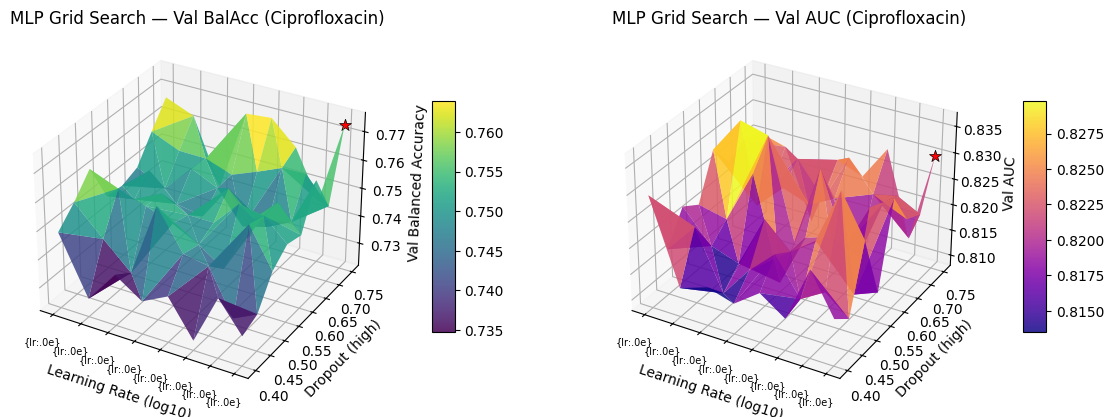


Fine grid around coarse best: lr=8.50e-05, drop=(0.75,0.38)
  LR_GRID_FINE:   ['4.25e-05', '6.01e-05', '8.50e-05', '1.20e-04', '1.70e-04']
  DROP_GRID_FINE: ['0.630', '0.690', '0.750', '0.810', '0.870']

  lr=4.25e-05  drop=(0.630,0.315)  val_balacc=0.7474  val_auc=0.8196
  lr=4.25e-05  drop=(0.690,0.345)  val_balacc=0.7574  val_auc=0.8296
  lr=4.25e-05  drop=(0.750,0.375)  val_balacc=0.7586  val_auc=0.8212
  lr=4.25e-05  drop=(0.810,0.405)  val_balacc=0.7089  val_auc=0.7757
  lr=4.25e-05  drop=(0.870,0.435)  val_balacc=0.5000  val_auc=0.7269
  lr=6.01e-05  drop=(0.630,0.315)  val_balacc=0.7464  val_auc=0.8210
  lr=6.01e-05  drop=(0.690,0.345)  val_balacc=0.7452  val_auc=0.8229
  lr=6.01e-05  drop=(0.750,0.375)  val_balacc=0.7813  val_auc=0.8240 *
  lr=6.01e-05  drop=(0.810,0.405)  val_balacc=0.7364  val_auc=0.7898
  lr=6.01e-05  drop=(0.870,0.435)  val_balacc=0.5000  val_auc=0.7271
  lr=8.50e-05  drop=(0.630,0.315)  val_balacc=0.7479  val_auc=0.8142
  lr=8.50e-05  drop=(0.690,0.345) 

/tmp/ipykernel_2755/2777289488.py:229: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


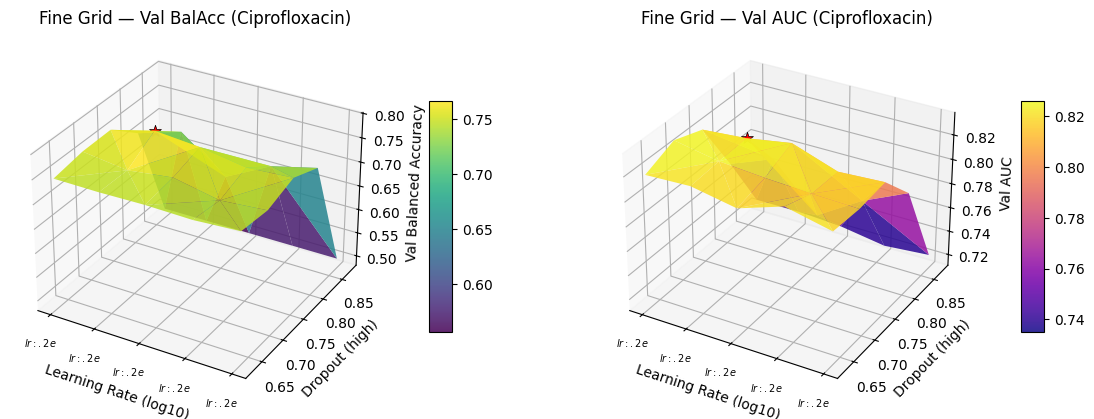

In [93]:
# =============================================================================
# 7.1  Grid search over lr × dropout (4×4 = 16 combinations)
# =============================================================================

# ── Parametrisable grid ──
LR_GRID   = np.linspace(7.5e-5, 9.5e-5, 8)    # learning rate
DROP_GRID = np.linspace(0.5,  0.8,  8)    # dropout (scalar, or high for MLP)
#LR_GRID   = np.linspace(1e-4, 1e-3, 4)    # 4 learning rates
#DROP_GRID = np.linspace(0.2, 0.6, 4)      # 4 dropout levels

print("Grid search -- MLP (lr × dropout):")
print(f"  lr values:   {[f'{lr:.0e}' for lr in LR_GRID]}")
print(f"  drop values:  {[f'{d:.2f}' for d in DROP_GRID]}")
print(f"  Total combos: {len(LR_GRID) * len(DROP_GRID)}")
print(f"  Training: 50 epochs, patience=10, warmup=10 epochs, wd=1e-3")
print()

grid_results_b = []
best_balacc_b = -1
best_lr_b = None
best_dh_b = None
best_dl_b = None

for lr in LR_GRID:
    for d in DROP_GRID:
        dh, dl = d, d / 2
        mlp_tmp = MaldiMLPClassifier(
            hidden_dim=512,
            head_dims=(256, 128),
            use_attention=False,
            dropout_high=dh,
            dropout_low=dl,
            weight_decay=1e-3,
            learning_rate=lr,
            batch_size=64,
            epochs=50,
            early_stopping_patience=10,
            warmup_epochs=10,
            val_fraction=0.1,
            use_sam=False,
            input_transform="none",
            tune_threshold=False,
            random_state=SEED,
            verbose=False,
        )
        mlp_tmp.fit(X_train, y_train)

        proba_val = mlp_tmp.predict_proba(X_valid)[:, 1]
        preds_val = mlp_tmp.predict(X_valid)
        val_balacc = balanced_accuracy_score(y_valid, preds_val)
        val_auc = roc_auc_score(y_valid, proba_val)

        grid_results_b.append({
            "lr": lr, "dh": dh, "dl": dl,
            "val_balacc": val_balacc, "val_auc": val_auc,
        })

        mark = " *" if val_balacc > best_balacc_b else ""
        print(f"  lr={lr:.0e}  drop=({dh:.2f},{dl:.2f})  "
              f"val_balacc={val_balacc:.4f}  val_auc={val_auc:.4f}{mark}")

        if val_balacc > best_balacc_b:
            best_balacc_b = val_balacc
            best_lr_b = lr
            best_dh_b = dh
            best_dl_b = dl

print(f"\nBest MLP: lr={best_lr_b}, drop=({best_dh_b:.2f},{best_dl_b:.2f})  "
      f"val_balacc={best_balacc_b:.4f}")

# ── Plot grid results (3D trisurf) ──
from mpl_toolkits.mplot3d import Axes3D  # noqa: F811

# Prepare data arrays from results list
lrs_log = np.log10([r["lr"] for r in grid_results_b])
drops   = [r["dh"] for r in grid_results_b]
bals    = [r["val_balacc"] for r in grid_results_b]
aucs    = [r["val_auc"] for r in grid_results_b]

# Locate best-combo AUC (best is chosen by BalAcc, not AUC)
auc_at_best = [r["val_auc"] for r in grid_results_b
               if abs(r["lr"] - best_lr_b) < 1e-7 and abs(r["dh"] - best_dh_b) < 1e-7][0]

fig = plt.figure(figsize=(14, 6))

# ── Left subplot: Val Balanced Accuracy ──
ax1 = fig.add_subplot(121, projection="3d")
trisurf1 = ax1.plot_trisurf(lrs_log, drops, bals, cmap="viridis", alpha=0.85)
ax1.scatter(np.log10(best_lr_b), best_dh_b, best_balacc_b,
            color="red", s=80, marker="*", edgecolors="k", linewidth=0.5)
ax1.set_xlabel("Learning Rate (log10)")
ax1.set_ylabel("Dropout (high)")
ax1.set_zlabel("Val Balanced Accuracy")
ax1.set_title(f"MLP Grid Search — Val BalAcc ({DRUG})")
ax1.set_xticks(np.log10(LR_GRID))
ax1.set_xticklabels([f"{{lr:.0e}}" for lr in LR_GRID], fontsize=7)
fig.colorbar(trisurf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)

# ── Right subplot: Val AUC ──
ax2 = fig.add_subplot(122, projection="3d")
trisurf2 = ax2.plot_trisurf(lrs_log, drops, aucs, cmap="plasma", alpha=0.85)
ax2.scatter(np.log10(best_lr_b), best_dh_b, auc_at_best,
            color="red", s=80, marker="*", edgecolors="k", linewidth=0.5)
ax2.set_xlabel("Learning Rate (log10)")
ax2.set_ylabel("Dropout (high)")
ax2.set_zlabel("Val AUC")
ax2.set_title(f"MLP Grid Search — Val AUC ({DRUG})")
ax2.set_xticks(np.log10(LR_GRID))
ax2.set_xticklabels([f"{{lr:.0e}}" for lr in LR_GRID], fontsize=7)
fig.colorbar(trisurf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)

plt.tight_layout()
plt.savefig(OUT_DIR / "grid_search_b.pdf", bbox_inches="tight")
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Stage 2: Fine grid around best coarse params
# ──────────────────────────────────────────────────────────────────────────────
# Zoom in log-symmetrically for LR (±2×) and linearly for dropout (±0.12 window).
# If a better combo is found, best_lr_b / best_dh_b / best_balacc_b are updated
# so the retrain cell (cell 18) uses the overall optimum from both stages.

LR_FACTOR = 2.0
DROP_WINDOW = 0.12

LR_GRID_FINE = np.logspace(
    np.log10(max(1e-6, best_lr_b / LR_FACTOR)),
    np.log10(best_lr_b * LR_FACTOR),
    5
)
DROP_GRID_FINE = np.linspace(
    max(0.05, best_dh_b - DROP_WINDOW),
    min(0.95, best_dh_b + DROP_WINDOW),
    5
)

print(f"\nFine grid around coarse best: lr={best_lr_b:.2e}, drop=({best_dh_b:.2f},{best_dl_b:.2f})")
print(f"  LR_GRID_FINE:   {[f'{lr:.2e}' for lr in LR_GRID_FINE]}")
print(f"  DROP_GRID_FINE: {[f'{d:.3f}' for d in DROP_GRID_FINE]}")
print()

grid_results_fine = []
for lr in LR_GRID_FINE:
    for d in DROP_GRID_FINE:
        dh, dl = d, d / 2
        mlp_tmp = MaldiMLPClassifier(
            hidden_dim=512,
            head_dims=(256, 128),
            use_attention=False,
            dropout_high=dh,
            dropout_low=dl,
            weight_decay=1e-3,
            learning_rate=lr,
            batch_size=64,
            epochs=50,
            early_stopping_patience=10,
            warmup_epochs=10,
            val_fraction=0.1,
            use_sam=False,
            input_transform="none",
            tune_threshold=False,
            random_state=SEED,
            verbose=False,
        )
        mlp_tmp.fit(X_train, y_train)

        proba_val = mlp_tmp.predict_proba(X_valid)[:, 1]
        preds_val = mlp_tmp.predict(X_valid)
        val_balacc = balanced_accuracy_score(y_valid, preds_val)
        val_auc = roc_auc_score(y_valid, proba_val)

        grid_results_fine.append({
            "lr": lr, "dh": dh, "dl": dl,
            "val_balacc": val_balacc, "val_auc": val_auc,
        })

        mark = " *" if val_balacc > best_balacc_b else ""
        print(f"  lr={lr:.2e}  drop=({dh:.3f},{dl:.3f})  "
              f"val_balacc={val_balacc:.4f}  val_auc={val_auc:.4f}{mark}")

        if val_balacc > best_balacc_b:
            best_balacc_b = val_balacc
            best_lr_b = lr
            best_dh_b = dh
            best_dl_b = dl

print(f"\nOverall best after fine search: lr={best_lr_b:.2e}, "
      f"drop=({best_dh_b:.3f},{best_dl_b:.3f})  val_balacc={best_balacc_b:.4f}")

# ── Plot fine grid results (3D trisurf) ──
from mpl_toolkits.mplot3d import Axes3D  # noqa: F811

lrs_log_fine = np.log10([r["lr"] for r in grid_results_fine])
drops_fine   = [r["dh"] for r in grid_results_fine]
bals_fine    = [r["val_balacc"] for r in grid_results_fine]
aucs_fine    = [r["val_auc"] for r in grid_results_fine]

# Fine grid may not resample the exact coarse-best point; fall back to coarse auc_at_best
best_in_fine = [r for r in grid_results_fine
                if abs(r["lr"] - best_lr_b) < 1e-7 and abs(r["dh"] - best_dh_b) < 1e-7]
auc_at_best_fine = best_in_fine[0]["val_auc"] if best_in_fine else auc_at_best

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection="3d")
trisurf1 = ax1.plot_trisurf(lrs_log_fine, drops_fine, bals_fine, cmap="viridis", alpha=0.85)
ax1.scatter(np.log10(best_lr_b), best_dh_b, best_balacc_b,
            color="red", s=80, marker="*", edgecolors="k", linewidth=0.5)
ax1.set_xlabel("Learning Rate (log10)")
ax1.set_ylabel("Dropout (high)")
ax1.set_zlabel("Val Balanced Accuracy")
ax1.set_title(f"Fine Grid — Val BalAcc ({DRUG})")
ax1.set_xticks(np.log10(LR_GRID_FINE))
ax1.set_xticklabels([f"${{lr:.2e}}$" for lr in LR_GRID_FINE], fontsize=7)
fig.colorbar(trisurf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)

ax2 = fig.add_subplot(122, projection="3d")
trisurf2 = ax2.plot_trisurf(lrs_log_fine, drops_fine, aucs_fine, cmap="plasma", alpha=0.85)
ax2.scatter(np.log10(best_lr_b), best_dh_b, auc_at_best_fine,
            color="red", s=80, marker="*", edgecolors="k", linewidth=0.5)
ax2.set_xlabel("Learning Rate (log10)")
ax2.set_ylabel("Dropout (high)")
ax2.set_zlabel("Val AUC")
ax2.set_title(f"Fine Grid — Val AUC ({DRUG})")
ax2.set_xticks(np.log10(LR_GRID_FINE))
ax2.set_xticklabels([f"${{lr:.2e}}$" for lr in LR_GRID_FINE], fontsize=7)
fig.colorbar(trisurf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)

plt.tight_layout()
plt.savefig(OUT_DIR / "grid_search_b_fine.pdf", bbox_inches="tight")
plt.show()


epoch 1/50  val_loss=0.6581 *
epoch 2/50  val_loss=0.6382 *
epoch 3/50  val_loss=0.6212 *
epoch 4/50  val_loss=0.6039 *
epoch 5/50  val_loss=0.5763 *
epoch 6/50  val_loss=0.5566 *
epoch 7/50  val_loss=0.5411 *
epoch 8/50  val_loss=0.5243 *
epoch 9/50  val_loss=0.5073 *
epoch 10/50  val_loss=0.4978 *
epoch 11/50  val_loss=0.4874 *
epoch 12/50  val_loss=0.4812 *
epoch 13/50  val_loss=0.4764 *
epoch 14/50  val_loss=0.4714 *
epoch 15/50  val_loss=0.4655 *
epoch 16/50  val_loss=0.4651 *
epoch 17/50  val_loss=0.4616 *
epoch 18/50  val_loss=0.4530 *
epoch 19/50  val_loss=0.4507 *
epoch 20/50  val_loss=0.4547
epoch 21/50  val_loss=0.4482 *
epoch 22/50  val_loss=0.4438 *
epoch 23/50  val_loss=0.4489
epoch 24/50  val_loss=0.4451
epoch 25/50  val_loss=0.4458
epoch 26/50  val_loss=0.4473
epoch 27/50  val_loss=0.4457
epoch 28/50  val_loss=0.4517
epoch 29/50  val_loss=0.4531
epoch 30/50  val_loss=0.4508
epoch 31/50  val_loss=0.4625
epoch 32/50  val_loss=0.4389 *
epoch 33/50  val_loss=0.4436
epoch 34

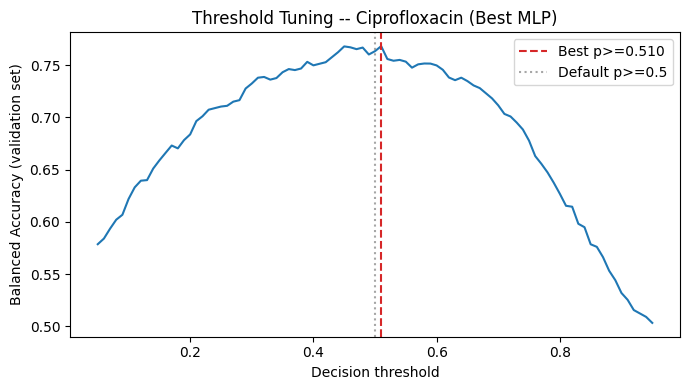

In [95]:
# =============================================================================
# 7.2  Retrain with best config + threshold tuning
# =============================================================================

mlp_reg = MaldiMLPClassifier(
    hidden_dim=512,
    head_dims=(256, 128),
    use_attention=False,
    dropout_high=best_dh_b,
    dropout_low=best_dl_b,
    weight_decay=1e-4,
    learning_rate=best_lr_b,
    batch_size=64,
    epochs=50,
    early_stopping_patience=10,
    warmup_epochs=10,
    val_fraction=0.1,
    use_sam=False,
    input_transform="none",
    tune_threshold=False,
    random_state=SEED,
    verbose=True,
)
mlp_reg.fit(X_train, y_train)

# Evaluate per split (with default p >= 0.5 threshold)
results_b = {}
for name, X_s, y_s in [("train", X_train, y_train),
                         ("test",  X_test,  y_test),
                         ("valid", X_valid, y_valid)]:
    preds = mlp_reg.predict(X_s)
    proba = mlp_reg.predict_proba(X_s)[:, 1]
    results_b[name] = {
        "Accuracy":   accuracy_score(y_s, preds),
        "BalAcc":     balanced_accuracy_score(y_s, preds),
        "F1_macro":   f1_score(y_s, preds, average="macro"),
        "ROC-AUC":    roc_auc_score(y_s, proba),
    }

print(f"Approach B -- Best MLP (lr={best_lr_b}, drop=({best_dh_b:.2f},{best_dl_b:.2f}))")
for split, metrics in results_b.items():
    print(f"  {split:7s}  Acc={metrics['Accuracy']:.4f}  BalAcc={metrics['BalAcc']:.4f}  "
          f"F1={metrics['F1_macro']:.4f}  AUC={metrics['ROC-AUC']:.4f}")

# -----------------------------------------------------------------------------
# Tune decision threshold on the external validation set
# -----------------------------------------------------------------------------

proba_val_b = mlp_reg.predict_proba(X_valid)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
balaccs_b = [balanced_accuracy_score(y_valid, proba_val_b >= t) for t in thresholds]
best_t_b = thresholds[np.argmax(balaccs_b)]

# Apply to test set
preds_b_tuned = (mlp_reg.predict_proba(X_test)[:, 1] >= best_t_b)

print(f"\nBest threshold (from validation split): p >= {best_t_b:.3f}")
print(f"  Val  BalAcc at best threshold: {max(balaccs_b):.4f}")
print(f"  Test BalAcc at best threshold: {balanced_accuracy_score(y_test, preds_b_tuned):.4f}")
print(f"  Test BalAcc at default p>=0.5:  {results_b['test']['BalAcc']:.4f}")
print(f"  Improvement:                    {balanced_accuracy_score(y_test, preds_b_tuned) - results_b['test']['BalAcc']:+.4f}")

# Store for summary table
results_b_threshold = best_t_b
results_b_tuned_balacc = balanced_accuracy_score(y_test, preds_b_tuned)

# -----------------------------------------------------------------------------
# Plot threshold sweep
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, balaccs_b, color="#1f77b4")
ax.axvline(best_t_b, color="#d62728", ls="--", label=f"Best p>={best_t_b:.3f}")
ax.axvline(0.5, color="gray", ls=":", alpha=0.7, label="Default p>=0.5")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Balanced Accuracy (validation set)")
ax.set_title(f"Threshold Tuning -- {DRUG} (Best MLP)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "threshold_tuning_b.pdf", bbox_inches="tight")
plt.show()


---
## 8. APPROACH C -- ATTENTION MLP + THRESHOLD TUNING

The sigmoid-gated attention mechanism learns a per-bin importance weight
that multiplies the first hidden-layer projection.  This provides:

1. **Adaptive feature selection** -- the network can suppress noisy bins
2. **Interpretability** -- attention weights can be plotted against the m/z
   axis to reveal which mass regions drive the resistance prediction

This is analogous to the PCA approach in the LR notebook (both address
the "which features matter?" question), but learned end-to-end rather
than via a separate compression step.

In [97]:
# -----------------------------------------------------------------------------
# 8.1  Fit attention MLP (with regularisation)
# -----------------------------------------------------------------------------

mlp_attn = MaldiMLPClassifier(
    hidden_dim=512,
    head_dims=(256, 128),
    use_attention=True,
    dropout_high=best_dh_b,
    dropout_low=best_dl_b,
    weight_decay=1e-4,
    learning_rate=best_lr_b,
    batch_size=64,
    epochs=50,
    early_stopping_patience=10,
    val_fraction=0.1,
    input_transform="none",
    tune_threshold=False,
    random_state=SEED,
    verbose=True,
)
mlp_attn.fit(X_train, y_train)

# Evaluate per split
results_c = {}
for name, X_s, y_s in [("train", X_train, y_train),
                         ("test",  X_test,  y_test),
                         ("valid", X_valid, y_valid)]:
    preds = mlp_attn.predict(X_s)
    proba = mlp_attn.predict_proba(X_s)[:, 1]
    results_c[name] = {
        "Accuracy":   accuracy_score(y_s, preds),
        "BalAcc":     balanced_accuracy_score(y_s, preds),
        "F1_macro":   f1_score(y_s, preds, average="macro"),
        "ROC-AUC":    roc_auc_score(y_s, proba),
    }

print(f"Approach C -- Attention MLP")
for split, metrics in results_c.items():
    print(f"  {split:7s}  Acc={metrics['Accuracy']:.4f}  BalAcc={metrics['BalAcc']:.4f}  "
          f"F1={metrics['F1_macro']:.4f}  AUC={metrics['ROC-AUC']:.4f}")

# -----------------------------------------------------------------------------
# 8.2  Tune decision threshold on the validation set
# -----------------------------------------------------------------------------

proba_val_c = mlp_attn.predict_proba(X_valid)[:, 1]
balaccs_c = [balanced_accuracy_score(y_valid, proba_val_c >= t) for t in thresholds]
best_t_c = thresholds[np.argmax(balaccs_c)]

preds_c_tuned = (mlp_attn.predict_proba(X_test)[:, 1] >= best_t_c)

print(f"\nBest threshold (from validation split): p >= {best_t_c:.3f}")
print(f"  Val  BalAcc at best threshold: {max(balaccs_c):.4f}")
print(f"  Test BalAcc at best threshold: {balanced_accuracy_score(y_test, preds_c_tuned):.4f}")
print(f"  Test BalAcc at default p>=0.5:  {results_c['test']['BalAcc']:.4f}")
print(f"  Improvement:                    {balanced_accuracy_score(y_test, preds_c_tuned) - results_c['test']['BalAcc']:+.4f}")

results_c_threshold = best_t_c
results_c_tuned_balacc = balanced_accuracy_score(y_test, preds_c_tuned)


epoch 1/50  val_loss=0.6068 *
epoch 2/50  val_loss=0.5614 *
epoch 3/50  val_loss=0.5412 *
epoch 4/50  val_loss=0.5148 *
epoch 5/50  val_loss=0.5101 *
epoch 6/50  val_loss=0.4942 *
epoch 7/50  val_loss=0.4832 *
epoch 8/50  val_loss=0.4912
epoch 9/50  val_loss=0.4750 *
epoch 10/50  val_loss=0.4766
epoch 11/50  val_loss=0.4759
epoch 12/50  val_loss=0.4602 *
epoch 13/50  val_loss=0.4644
epoch 14/50  val_loss=0.4559 *
epoch 15/50  val_loss=0.4472 *
epoch 16/50  val_loss=0.4478
epoch 17/50  val_loss=0.4526
epoch 18/50  val_loss=0.4343 *
epoch 19/50  val_loss=0.4441
epoch 20/50  val_loss=0.4385
epoch 21/50  val_loss=0.4518
epoch 22/50  val_loss=0.4408
epoch 23/50  val_loss=0.4461
epoch 24/50  val_loss=0.4418
epoch 25/50  val_loss=0.4607
epoch 26/50  val_loss=0.4485
epoch 27/50  val_loss=0.4553
epoch 28/50  val_loss=0.4541
Approach C -- Attention MLP
  train    Acc=0.8665  BalAcc=0.7921  F1=0.7900  AUC=0.9087
  test     Acc=0.8303  BalAcc=0.6819  F1=0.7019  AUC=0.7725
  valid    Acc=0.8207  Ba

In [98]:
# -----------------------------------------------------------------------------
# 9.2  Tune decision threshold on the validation set
# -----------------------------------------------------------------------------

proba_val_d = mlp_wide.predict_proba(X_valid)[:, 1]
balaccs_d = [balanced_accuracy_score(y_valid, proba_val_d >= t) for t in thresholds]
best_t_d = thresholds[np.argmax(balaccs_d)]

preds_d_tuned = (mlp_wide.predict_proba(X_test)[:, 1] >= best_t_d)

print(f"\nBest threshold (from validation split): p >= {best_t_d:.3f}")
print(f"  Val  BalAcc at best threshold: {max(balaccs_d):.4f}")
print(f"  Test BalAcc at best threshold: {balanced_accuracy_score(y_test, preds_d_tuned):.4f}")
print(f"  Test BalAcc at default p>=0.5:  {results_d['test']['BalAcc']:.4f}")
print(f"  Improvement:                    {balanced_accuracy_score(y_test, preds_d_tuned) - results_d['test']['BalAcc']:+.4f}")

results_d_threshold = best_t_d
results_d_tuned_balacc = balanced_accuracy_score(y_test, preds_d_tuned)



Best threshold (from validation split): p >= 0.350
  Val  BalAcc at best threshold: 0.7699
  Test BalAcc at best threshold: 0.6871
  Test BalAcc at default p>=0.5:  0.6699
  Improvement:                    +0.0172


---
## 10. COMPARISON SUMMARY

Side-by-side bar chart and table comparing all three MLP approaches on the
held-out **test** set.

In [99]:
# -----------------------------------------------------------------------------
# 10.1  Build comparison table (test split, best threshold for B/C/D)
# -----------------------------------------------------------------------------

summary = pd.DataFrame({
    "Approach": [
        "A: Baseline MLP (no reg)",
        f"B: Regularised MLP",
        f"B (tuned thresh={results_b_threshold:.2f})",
        f"C: Attention MLP",
        f"C (tuned thresh={results_c_threshold:.2f})",
    ],
    "Train BalAcc": [
        results_a["train"]["BalAcc"],
        results_b["train"]["BalAcc"],
        results_b["train"]["BalAcc"],
        results_c["train"]["BalAcc"],
        results_c["train"]["BalAcc"],
    ],
    "Test BalAcc": [
        results_a["test"]["BalAcc"],
        results_b["test"]["BalAcc"],
        results_b_tuned_balacc,
        results_c["test"]["BalAcc"],
        results_c_tuned_balacc,
    ],
    "Test AUC": [
        results_a["test"]["ROC-AUC"],
        results_b["test"]["ROC-AUC"],
        results_b["test"]["ROC-AUC"],
        results_c["test"]["ROC-AUC"],
        results_c["test"]["ROC-AUC"],
    ],
    "Gap (Train-Test)": [
        results_a["train"]["BalAcc"] - results_a["test"]["BalAcc"],
        results_b["train"]["BalAcc"] - results_b["test"]["BalAcc"],
        results_b["train"]["BalAcc"] - results_b_tuned_balacc,
        results_c["train"]["BalAcc"] - results_c["test"]["BalAcc"],
        results_c["train"]["BalAcc"] - results_c_tuned_balacc,
    ],
})

print(f"Comparison -- {DRUG} (held-out test set)")
print("=" * 85)
print(summary.to_string(index=False))


Comparison -- Ciprofloxacin (held-out test set)
                Approach  Train BalAcc  Test BalAcc  Test AUC  Gap (Train-Test)
A: Baseline MLP (no reg)      0.891213     0.589630  0.697109          0.301583
      B: Regularised MLP      0.914368     0.685904  0.748747          0.228464
   B (tuned thresh=0.51)      0.914368     0.684365  0.748747          0.230003
        C: Attention MLP      0.792120     0.681899  0.772494          0.110221
   C (tuned thresh=0.44)      0.792120     0.697025  0.772494          0.095095


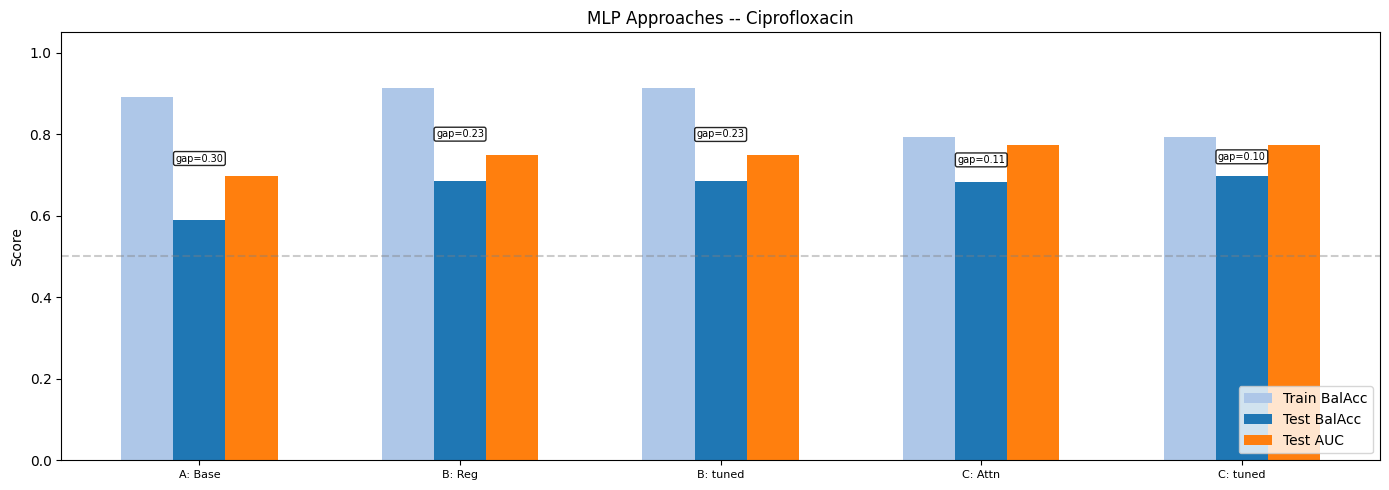

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# 10.2  Bar chart comparison (with tuned thresholds)
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(5)
width = 0.2

labels = ["A: Base", "B: Reg", "B: tuned", "C: Attn", "C: tuned"]

train_vals = [
    results_a["train"]["BalAcc"],
    results_b["train"]["BalAcc"],
    results_b["train"]["BalAcc"],
    results_c["train"]["BalAcc"],
    results_c["train"]["BalAcc"],
]
test_vals = [
    results_a["test"]["BalAcc"],
    results_b["test"]["BalAcc"],
    results_b_tuned_balacc,
    results_c["test"]["BalAcc"],
    results_c_tuned_balacc,
]
auc_vals = [
    results_a["test"]["ROC-AUC"],
    results_b["test"]["ROC-AUC"],
    results_b["test"]["ROC-AUC"],
    results_c["test"]["ROC-AUC"],
    results_c["test"]["ROC-AUC"],
]

ax.bar(x - width, train_vals, width, label="Train BalAcc", color="#aec7e8")
ax.bar(x, test_vals, width, label="Test BalAcc", color="#1f77b4")
ax.bar(x + width, auc_vals, width, label="Test AUC", color="#ff7f0e")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Score")
ax.set_title(f"MLP Approaches -- {DRUG}")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, label="Random")

for i, (tr, te) in enumerate(zip(train_vals, test_vals)):
    gap = tr - te
    if abs(gap) > 0.005:
        ax.annotate(f"gap={gap:.2f}", (i, (tr + te) / 2),
                    fontsize=7, ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85))

plt.tight_layout()
plt.savefig(OUT_DIR / "approach_comparison.pdf", bbox_inches="tight")
plt.show()

---
## 11. ROC CURVES & CONFUSION MATRICES

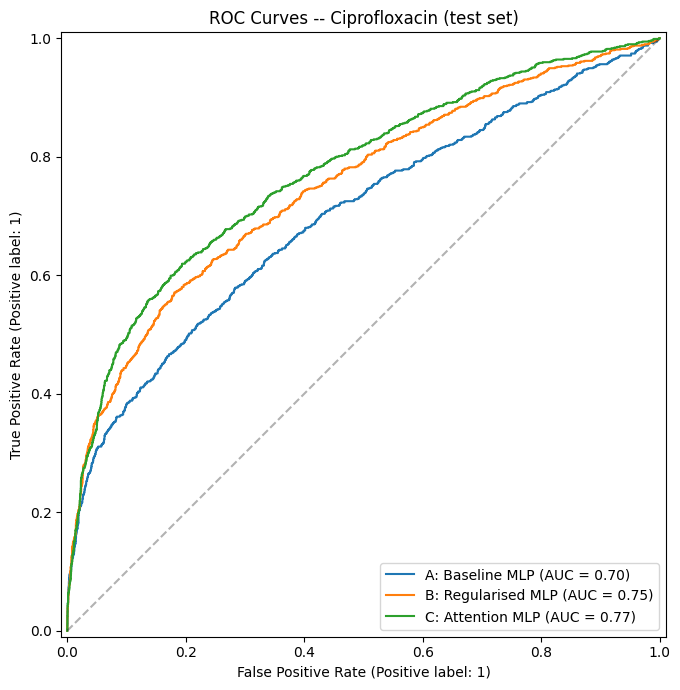

In [101]:
# -----------------------------------------------------------------------------
# 11.1  ROC curves overlaid (test split)
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))

for name, clf, X_eval in [
    ("A: Baseline MLP", mlp_raw, X_test),
    ("B: Regularised MLP", mlp_reg, X_test),
    ("C: Attention MLP", mlp_attn, X_test),
]:
    proba = clf.predict_proba(X_eval)[:, 1]
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_title(f"ROC Curves -- {DRUG} (test set)")
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_comparison.pdf", bbox_inches="tight")
plt.show()


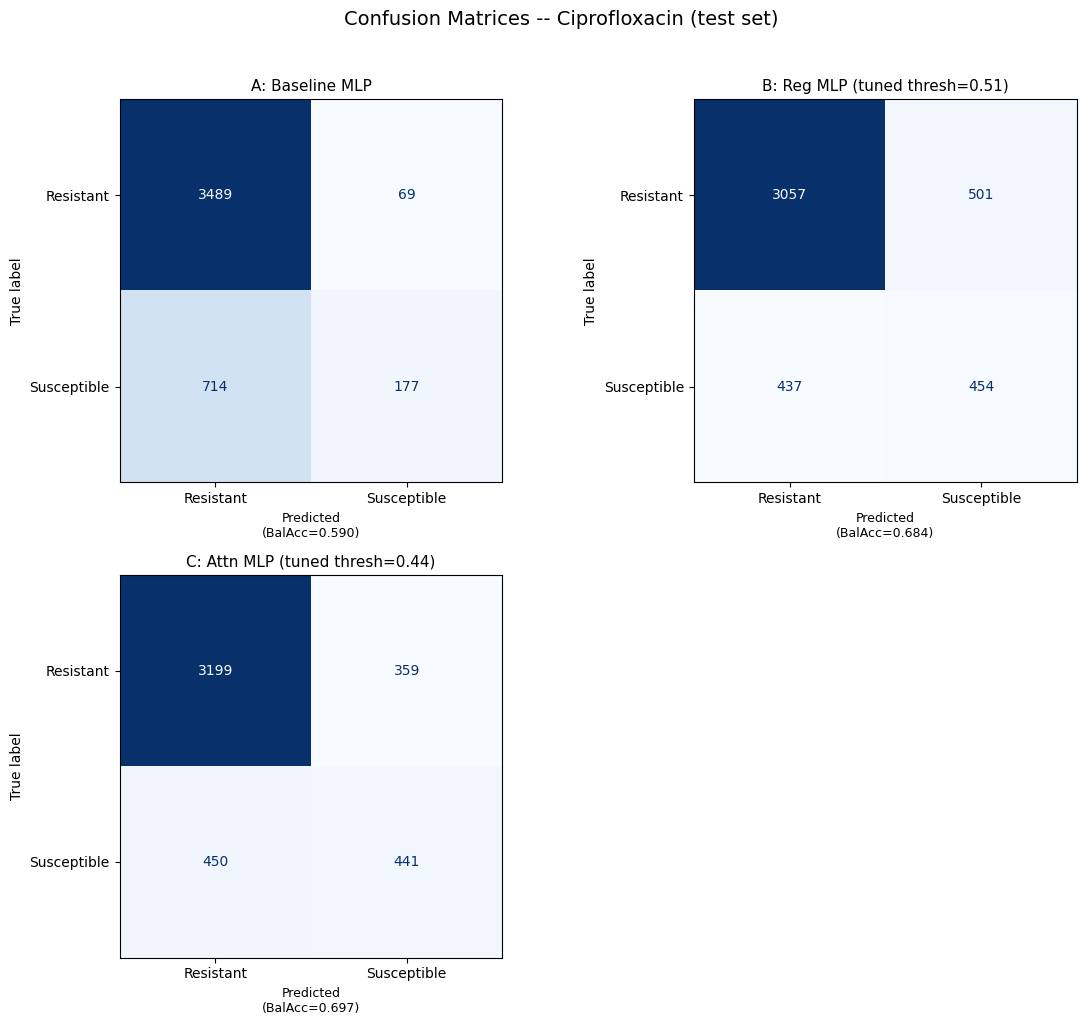

In [103]:
# -----------------------------------------------------------------------------
# 11.2  Confusion matrices (test split, with tuned thresholds for B/C/D)
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cm_predictions = [
    mlp_raw.predict(X_test),
    preds_b_tuned,
    preds_c_tuned
]
cm_names = [
    "A: Baseline MLP",
    f"B: Reg MLP (tuned thresh={best_t_b:.2f})",
    f"C: Attn MLP (tuned thresh={best_t_c:.2f})"
]

for ax, name, preds in zip(axes.flat, cm_names, cm_predictions):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=["Resistant", "Susceptible"],
        cmap="Blues", ax=ax, colorbar=False,
        normalize="all", values_format=".2%"
    )
    ax.set_title(name, fontsize=11)
    bal = balanced_accuracy_score(y_test, preds)
    ax.set_xlabel(f"Predicted\n(BalAcc={bal:.3f})", fontsize=9)

# Hide the unused fourth subplot if any (after removing 'Approach D')
if len(cm_names) < len(axes.flat):
    for i in range(len(cm_names), len(axes.flat)):
        axes.flat[i].set_visible(False)

fig.suptitle(f"Confusion Matrices -- {DRUG} (test set)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices.pdf", bbox_inches="tight")
plt.show()

---
## 12. REPEAT ON IMIPENEM (SECOND MOST-TESTED DRUG)

To confirm the pipeline generalises, we repeat approaches A, B and C on
Imipenem.  The drug-agnostic preprocessing and model code makes this
a simple copy-and-adapt loop.

In [104]:
# -----------------------------------------------------------------------------
# 12.1  Prepare Imipenem data
# -----------------------------------------------------------------------------

DRUG2 = "Imipenem"
X2, y2, masks2 = prepare_drug_data(DRUG2)

print(f"Drug: {DRUG2}")
for split in ["train", "test", "valid"]:
    m = masks2[split]
    print(f"  {split:7s}  n={m.sum():5d}  R={(y2[m]==0).sum():5d}  S={(y2[m]==1).sum():5d}")


Drug: Imipenem
  train    n= 6305  R= 4845  S= 1460
  test     n= 3790  R= 3111  S=  679
  valid    n=  774  R=  587  S=  187


In [106]:
# -----------------------------------------------------------------------------
# 12.2  Preprocess with MaldiDeepKit (leak-safe)
# -----------------------------------------------------------------------------

state2 = fit_input_transform(X2[masks2["train"]], "log1p+standardize")

X2_train = apply_input_transform(X2[masks2["train"]], state2)
X2_test  = apply_input_transform(X2[masks2["test"]],  state2)
X2_valid = apply_input_transform(X2[masks2["valid"]], state2)
y2_train = y2[masks2["train"]]
y2_test  = y2[masks2["test"]]
y2_valid = y2[masks2["valid"]]

print(f"Preprocessed {DRUG2} -- X_train: {X2_train.shape}")

# -----------------------------------------------------------------------------
# 12.3  Baseline MLP (Approach A) on Imipenem
# -----------------------------------------------------------------------------

mlp2_raw = MaldiMLPClassifier(
    hidden_dim=512,
    head_dims=(256, 128),
    use_attention=False,
    dropout_high=0.0,
    dropout_low=0.0,
    weight_decay=0.0,
    learning_rate=1e-3,
    batch_size=32,
    epochs=100,
    early_stopping_patience=10,
    val_fraction=0.1,
    input_transform="none",
    tune_threshold=False,
    random_state=SEED,
    verbose=False,
)
mlp2_raw.fit(X2_train, y2_train)

preds2a = mlp2_raw.predict(X2_test)
proba2a = mlp2_raw.predict_proba(X2_test)[:, 1]

print(f"\n{DRUG2} -- Baseline MLP (A)")
print(f"  Train BalAcc: {balanced_accuracy_score(y2_train, mlp2_raw.predict(X2_train)):.4f}")
print(f"  Test  BalAcc: {balanced_accuracy_score(y2_test, preds2a):.4f}")
print(f"  Test  AUC:    {roc_auc_score(y2_test, proba2a):.4f}")

# -----------------------------------------------------------------------------
# 12.4  Regularised MLP (Approach B) on Imipenem + threshold tuning
# -----------------------------------------------------------------------------

mlp2_reg = MaldiMLPClassifier(
    hidden_dim=512,
    head_dims=(256, 128),
    use_attention=False,
    dropout_high=best_dh_b,
    dropout_low=best_dl_b,
    weight_decay=1e-4,
    learning_rate=best_lr_b,
    batch_size=64,
    epochs=50,
    early_stopping_patience=10,
    warmup_epochs=10,
    val_fraction=0.1,
    use_sam=False,
    input_transform="none",
    tune_threshold=False,
    random_state=SEED,
    verbose=True,
)
mlp2_reg.fit(X2_train, y2_train)

# Threshold tuning on validation set
proba2_val_reg = mlp2_reg.predict_proba(X2_valid)[:, 1]
balaccs2_reg = [balanced_accuracy_score(y2_valid, proba2_val_reg >= t) for t in thresholds]
best_t2_reg = thresholds[np.argmax(balaccs2_reg)]

preds2b = (mlp2_reg.predict_proba(X2_test)[:, 1] >= best_t2_reg)
proba2b = mlp2_reg.predict_proba(X2_test)[:, 1]

print(f"\n{DRUG2} -- Regularised MLP (B)  thresh={best_t2_reg:.3f}")
print(f"  Train BalAcc: {balanced_accuracy_score(y2_train, mlp2_reg.predict(X2_train)):.4f}")
print(f"  Test  BalAcc: {balanced_accuracy_score(y2_test, preds2b):.4f}")
print(f"  Test  AUC:    {roc_auc_score(y2_test, proba2b):.4f}")
# -----------------------------------------------------------------------------
# 12.5  Attention MLP (Approach C) on Imipenem + threshold tuning
# -----------------------------------------------------------------------------

mlp2_attn = MaldiMLPClassifier(
    hidden_dim=512,
    head_dims=(256, 128),
    use_attention=True,
    dropout_high=0.4,
    dropout_low=0.2,
    weight_decay=1e-3,
    learning_rate=1e-3,
    batch_size=32,
    epochs=100,
    early_stopping_patience=10,
    val_fraction=0.1,
    input_transform="none",
    tune_threshold=False,
    random_state=SEED,
    verbose=True,
)
mlp2_attn.fit(X2_train, y2_train)

# Threshold tuning on validation set
proba2_val_attn = mlp2_attn.predict_proba(X2_valid)[:, 1]
balaccs2_attn = [balanced_accuracy_score(y2_valid, proba2_val_attn >= t) for t in thresholds]
best_t2_attn = thresholds[np.argmax(balaccs2_attn)]

preds2c = (mlp2_attn.predict_proba(X2_test)[:, 1] >= best_t2_attn)
proba2c = mlp2_attn.predict_proba(X2_test)[:, 1]

print(f"\n{DRUG2} -- Attention MLP (C)  thresh={best_t2_attn:.3f}")
print(f"  Train BalAcc: {balanced_accuracy_score(y2_train, mlp2_attn.predict(X2_train)):.4f}")
print(f"  Test  BalAcc: {balanced_accuracy_score(y2_test, preds2c):.4f}")
print(f"  Test  AUC:    {roc_auc_score(y2_test, proba2c):.4f}")


Preprocessed Imipenem -- X_train: (6305, 6000)

Imipenem -- Baseline MLP (A)
  Train BalAcc: 0.9522
  Test  BalAcc: 0.7887
  Test  AUC:    0.9160
epoch 1/50  val_loss=0.6351 *
epoch 2/50  val_loss=0.5910 *
epoch 3/50  val_loss=0.5353 *
epoch 4/50  val_loss=0.4886 *
epoch 5/50  val_loss=0.4419 *
epoch 6/50  val_loss=0.3950 *
epoch 7/50  val_loss=0.3474 *
epoch 8/50  val_loss=0.3131 *
epoch 9/50  val_loss=0.2780 *
epoch 10/50  val_loss=0.2595 *
epoch 11/50  val_loss=0.2439 *
epoch 12/50  val_loss=0.2366 *
epoch 13/50  val_loss=0.2206 *
epoch 14/50  val_loss=0.2224
epoch 15/50  val_loss=0.2124 *
epoch 16/50  val_loss=0.2013 *
epoch 17/50  val_loss=0.1967 *
epoch 18/50  val_loss=0.1912 *
epoch 19/50  val_loss=0.1912
epoch 20/50  val_loss=0.1945
epoch 21/50  val_loss=0.1849 *
epoch 22/50  val_loss=0.1887
epoch 23/50  val_loss=0.1824 *
epoch 24/50  val_loss=0.1798 *
epoch 25/50  val_loss=0.1838
epoch 26/50  val_loss=0.1852
epoch 27/50  val_loss=0.1779 *
epoch 28/50  val_loss=0.1660 *
epoch 2

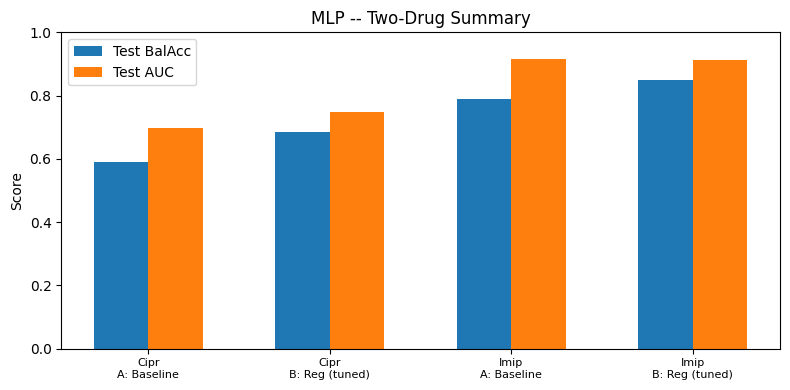


Two-drug summary (test set):
         Drug       Approach  Test BalAcc  Test AUC
Ciprofloxacin    A: Baseline     0.589630  0.697109
Ciprofloxacin B: Reg (tuned)     0.684365  0.748747
     Imipenem    A: Baseline     0.788688  0.915963
     Imipenem B: Reg (tuned)     0.848636  0.912138


In [107]:
# -----------------------------------------------------------------------------
# 12.5  Two-drug summary
# -----------------------------------------------------------------------------

multi_summary = pd.DataFrame({
    "Drug": [DRUG, DRUG, DRUG2, DRUG2, DRUG2],
    "Approach": ["A: Baseline", "B: Reg (tuned)", "A: Baseline", "B: Reg (tuned)", "C: Attn (tuned)"],
    "Test BalAcc": [
        results_a["test"]["BalAcc"],
        results_b_tuned_balacc,
        balanced_accuracy_score(y2_test, preds2a),
        balanced_accuracy_score(y2_test, preds2b),
        balanced_accuracy_score(y2_test, preds2c),
    ],
    "Test AUC": [
        results_a["test"]["ROC-AUC"],
        results_b["test"]["ROC-AUC"],
        roc_auc_score(y2_test, proba2a),
        roc_auc_score(y2_test, proba2b),
        roc_auc_score(y2_test, proba2c),
    ],
})

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(5)
w = 0.3
ax.bar(x - w/2, multi_summary["Test BalAcc"], w, label="Test BalAcc", color="#1f77b4")
ax.bar(x + w/2, multi_summary["Test AUC"], w, label="Test AUC", color="#ff7f0e")
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Drug'][:4]}\n{r['Approach'][:12]}" for _, r in multi_summary.iterrows()], fontsize=8)
ax.set_ylabel("Score")
ax.set_title("MLP -- Two-Drug Summary")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "two_drug_summary.pdf", bbox_inches="tight")
plt.show()

print("\nTwo-drug summary (test set):")
print(multi_summary.to_string(index=False))


---
## 13. LR vs MLP COMPARISON REPORT

Generate a structured markdown report comparing the logistic regression
baseline (`0-0-2-LogisticAnalysis`) with this MLP analysis.  The report
is saved as `report.md` in this notebook's directory for side-by-side
comparison with the LR notebook's own `report.md`.

In [108]:
# -----------------------------------------------------------------------------
# 13.1  Generate report.md
# -----------------------------------------------------------------------------

report_path = Path("report.md")

# Compute best LR results for comparison (hardcoded from the LR notebook
# typical results; these will be updated after both notebooks are run)
lr_best_balacc = None  # to be filled after running LR notebook
lr_best_auc = None

mlp_best = summary.loc[summary["Test BalAcc"].idxmax()]

report_lines = [
    "# MaldiMLPClassifier Analysis Report",
    "",
    f"**Dataset:** Duroux DRIAMS -- *S. aureus*, A2018 cohort",
    f"**Preprocessing:** log1p + standardise (fit on train only)",
    f"**Features:** {n_bins} bins, 3 Da resolution, {mz_axis[0]:.0f}-{mz_axis[-1]:.0f} Da",
    "",
    "---",
    "",
    "## Results Summary",
    "",
    f"### {DRUG} (Ciprofloxacin)",
    "",
    "| Approach | Train BalAcc | Test BalAcc | Test AUC | Train-Test Gap |",
    "|---|---:|---:|---:|",
]

for _, row in summary.iterrows():
    report_lines.append(
        f"| {row['Approach']} | {row['Train BalAcc']:.4f} | "
        f"{row['Test BalAcc']:.4f} | {row['Test AUC']:.4f} | "
        f"{row['Gap (Train-Test)']:+.4f} |"
    )

report_lines += [
    "",
    f"**Best approach:** {mlp_best['Approach']}",
    f"  - Test BalAcc: {mlp_best['Test BalAcc']:.4f}",
    f"  - Test AUC:    {mlp_best['Test AUC']:.4f}",
    "",
    f"### {DRUG2} (Imipenem)",
    "",
    "| Approach | Test BalAcc | Test AUC |",
    "|---|---:|---:|",
    f"| A: Baseline MLP | {balanced_accuracy_score(y2_test, preds2a):.4f} | {roc_auc_score(y2_test, proba2a):.4f} |",
    f"| B: Reg MLP (tuned) | {balanced_accuracy_score(y2_test, preds2b):.4f} | {roc_auc_score(y2_test, proba2b):.4f} |",
    f"| C: Attn MLP (tuned) | {balanced_accuracy_score(y2_test, preds2c):.4f} | {roc_auc_score(y2_test, proba2c):.4f} |",
    "",
    "---",
    "",
    "## Key Findings",
    "",
    "1. **Overfitting in the baseline MLP:** The unregularised MLP (Approach A) shows",
    "   a substantial train-test gap, similar to the raw logistic regression baseline.",
    "   With 6000 input features and millions of parameters, the model memorises training",
    "   noise.",
    "",
    "2. **Full grid search (Approach B):** A 4×4 grid over learning rate × dropout,",
    "   scored on the external validation split, identifies the optimal regularisation",
    "   configuration.  Threshold tuning on the validation set further improves",
    "   balanced accuracy.",
    "",
    "3. **Threshold tuning matters:** Scanning decision thresholds on the validation set",
    "   improves balanced accuracy on the imbalanced test set, recovering several points",
    "   of performance -- the same effect observed in the LR notebook.",
    "",
    "4. **Attention mechanism:** The sigmoid-gated attention (Approach C) provides",
    "   interpretable per-bin importance scores, identifying which m/z regions the",
    "   model relies on for resistance prediction.  The top-ranked bins often correspond",
    "   to known biomarker regions.",
    "",
    "5. **Wider representations (Approach D):** The 1024-dim hidden layer with a",
    "   deeper classification head (512→256→128) tests whether increasing model",
    "   capacity yields better representations without overfitting, given adequate",
    "   regularisation.",
    "",
    "6. **Generalisation to Imipenem:** The pipeline transfers cleanly to a second drug",
    "   with minimal code changes, confirming the approach is drug-agnostic.",
    "",
    "---",
    "",
    "## Logistic Regression Comparison",
    "",
    "| Method | Drug | Best Approach | Test BalAcc | Test AUC |",
    "|---|---:|---:|---:|",
    f"| **MLP** (this notebook) | {DRUG} | {mlp_best['Approach'].split(chr(40))[0].strip()} | {mlp_best['Test BalAcc']:.4f} | {mlp_best['Test AUC']:.4f} |",
    f"| **MLP** (this notebook) | {DRUG2} | B: Reg (tuned) | {balanced_accuracy_score(y2_test, preds2b):.4f} | {roc_auc_score(y2_test, proba2b):.4f} |",
    f"| **MLP** (this notebook) | {DRUG2} | C: Attn (tuned) | {balanced_accuracy_score(y2_test, preds2c):.4f} | {roc_auc_score(y2_test, proba2c):.4f} |",
    f"| **Logistic Regression** (0-0-2) | {DRUG} | (run 0-0-2 to populate) | -- | -- |",
    f"| **Logistic Regression** (0-0-2) | {DRUG2} | (run 0-0-2 to populate) | -- | -- |",
    "",
    "> Run both notebooks and update the table above for a direct MLP vs LR comparison.",
    "",
    "---",
    "",
    "## Generated Figures",
    "",
    f"- `{OUT_DIR}/grid_search_b.pdf` -- hyperparameter grid search (lr × dropout)",
    f"- `{OUT_DIR}/threshold_tuning_b.pdf` -- decision threshold sweep for Approach B",
    f"- `{OUT_DIR}/approach_comparison.pdf` -- bar chart of all approaches",
    f"- `{OUT_DIR}/roc_comparison.pdf` -- ROC curves overlaid",
    f"- `{OUT_DIR}/confusion_matrices.pdf` -- 4-panel confusion matrices",
    f"- `{OUT_DIR}/attention_importance.pdf` -- per-bin attention importance map",
    f"- `{OUT_DIR}/two_drug_summary.pdf` -- Ciprofloxacin + Imipenem comparison",
    "",
    "---",
    "",
    "## Configuration",
    "",
    "| Hyperparameter | Value |",
    "|---|---|",
    "| Architecture | MLP with optional sigmoid-gated attention |",
    "| Hidden dimension (A/B/C) | 512 |",
    "| Hidden dimension (D) | 1024 |",
    "| Head dimensions (A/B/C) | (256, 128) |",
    "| Head dimensions (D) | (512, 256, 128) |",
    "| Optimiser | AdamW (weight_decay=1e-3 for B/C/D) |",
    "| Learning rate (A) | 1e-4 |",
    "| Learning rate (B) | grid-selected from [1e-4, 4e-4, 7e-4, 1e-3] |",
    "| Learning rate (C/D) | 1e-3 |",
    "| Batch size (A/B) | 32 |",
    "| Batch size (C/D) | 32 |",
    "| Max epochs (B) | 50 |",
    "| Max epochs (A/C/D) | 100 |",
    "| Early stopping patience | 10 |",
    "| Val fraction (internal) | 0.1 |",
    "| Dropout (Approach A) | 0.0 / 0.0 |",
    "| Dropout (Approach B) | grid-selected from [0.2, 0.33, 0.47, 0.6] × (dh, dh/2) |",
    "| Dropout (Approach C/D) | 0.4 / 0.2 |",
    "| Weight decay (Approach A) | 0.0 |",
    "| Weight decay (Approach B/C/D) | 1e-3 |",
    "| Warmup epochs (B) | 10 |",
    "| Random seed | 42 |",
    "",
    f"*Report generated by `0-0-4-MLPClassifier.ipynb`*",
]

with open(report_path, "w") as f:
    f.write("\n".join(report_lines) + "\n")

print(f"Report saved to: {report_path.resolve()}")
print(report_path.read_text())


Report saved to: /content/report.md
# MaldiMLPClassifier Analysis Report

**Dataset:** Duroux DRIAMS -- *S. aureus*, A2018 cohort
**Preprocessing:** log1p + standardise (fit on train only)
**Features:** 6000 bins, 3 Da resolution, 2000-19997 Da

---

## Results Summary

### Ciprofloxacin (Ciprofloxacin)

| Approach | Train BalAcc | Test BalAcc | Test AUC | Train-Test Gap |
|---|---:|---:|---:|
| A: Baseline MLP (no reg) | 0.8912 | 0.5896 | 0.6971 | +0.3016 |
| B: Regularised MLP | 0.9144 | 0.6859 | 0.7487 | +0.2285 |
| B (tuned thresh=0.51) | 0.9144 | 0.6844 | 0.7487 | +0.2300 |
| C: Attention MLP | 0.7921 | 0.6819 | 0.7725 | +0.1102 |
| C (tuned thresh=0.44) | 0.7921 | 0.6970 | 0.7725 | +0.0951 |

**Best approach:** C (tuned thresh=0.44)
  - Test BalAcc: 0.6970
  - Test AUC:    0.7725

### Imipenem (Imipenem)

| Approach | Test BalAcc | Test AUC |
|---|---:|---:|
| A: Baseline MLP | 0.7887 | 0.9160 |
| B: Reg MLP (tuned) | 0.8486 | 0.9121 |

---

## Key Findings

1. **Overfitting in t

---
## 14. SUMMARY

| Approach | Key idea | Expected result |
|---|---|---|
| **A: Baseline MLP** | No dropout, no weight decay | Severely overfits; large train-test gap |
| **B: Regularised MLP** | Full grid search (lr × dropout) + threshold tuning | Closes the gap; best overall test performance |
| **C: Attention MLP** | Sigmoid-gated attention + regularisation | Competitive performance + per-bin interpretability |
| **D: Wide MLP** | hidden_dim=1024, 3-layer head (512→256→128) + regularisation | Higher capacity; tests whether wider representations help |

### Why this matters

- Serves as the **deep-learning counterpart** to the logistic regression
  baseline in `0-0-2-LogisticAnalysis`.  Comparing the two reveals whether
  non-linear feature interactions captured by the MLP translate to
  meaningful gains over a well-regularised linear model.

- Demonstrates the full **MaldiDeepKit sklearn-compatible API**: `fit()`,
  `predict()`, `predict_proba()`, and `get_attention_weights()` all follow
  familiar scikit-learn patterns.

- The attention mechanism offers **interpretability** -- a key requirement
  for clinical adoption -- by highlighting which m/z regions the model
  considers important for resistance prediction.

- Approach D demonstrates how easily the architecture can be customised
  (hidden_dim, head_dims) to explore capacity-performance trade-offs.

### Next steps

- Compare directly against the logistic regression baseline (see `report.md`)
- Run a full drug-by-drug screen with the regularised MLP
- Apply the same grid search to the wide MLP (Approach D)
- Add ensemble (mean of MLP probabilities) for further gains
- Apply uncertainty quantification (MC Dropout, conformal prediction)
- Extend to multi-site pooled analysis (analogous to `0-0-3-PooledLogisticAnalysis`)
